#Выполнили студенты 523 группы:
Суракий Диана, Чех Степан, Чиглинцев Илья, Капушев Сергей

In [ ]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 23.3 MB/s eta 0:00:00




---



In [ ]:
import pulp
import matplotlib.pyplot as plt
import numpy as np

# Задание 1.1
Решить графически задачу линейного программирования.
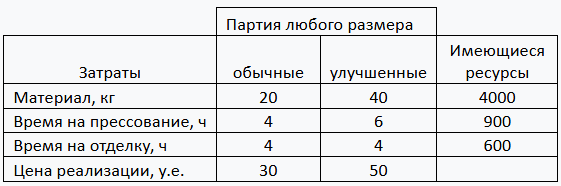\
Фирма выпускает два вида древесно-стружечных плит – обычные и улучшенные. При этом производятся две основные операции – прессование и отделка
Требуется определить, какое количество плит каждого типа можно изготовить в течение месяца так, чтобы обеспечить максимальную прибыль при имеющихся ограничениях на ресурсы (материал, время).

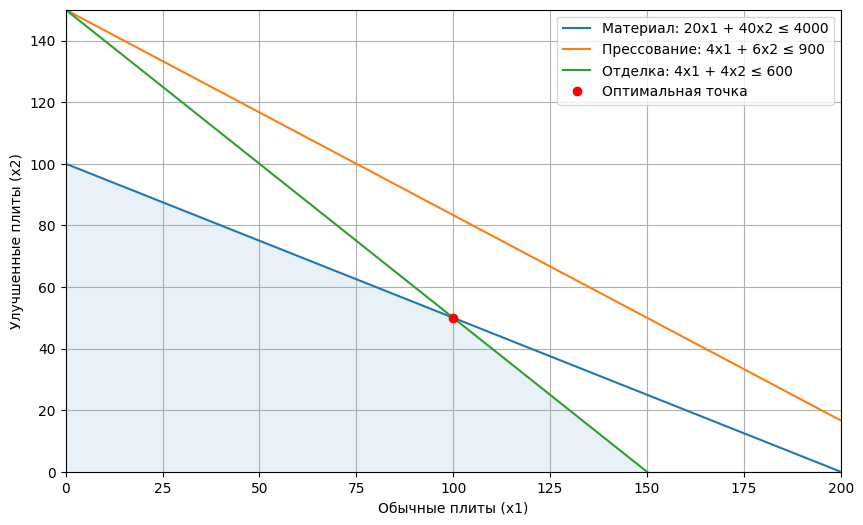

Оптимальное решение: x1 = 100.0, x2 = 50.0
Максимальная прибыль: 5500.0 у.е.


In [ ]:
# Ограничения
x = np.linspace(0, 200, 400)
y_material = (4000 - 20*x) / 40    # 20x1 + 40x2 <= 4000
y_press = (900 - 4*x) / 6          # 4x1 + 6x2 <= 900
y_finish = (600 - 4*x) / 4         # 4x1 + 4x2 <= 600

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(x, y_material, label="Материал: 20x1 + 40x2 ≤ 4000")
plt.plot(x, y_press, label="Прессование: 4x1 + 6x2 ≤ 900")
plt.plot(x, y_finish, label="Отделка: 4x1 + 4x2 ≤ 600")

# Настройка графика
plt.xlim(0, 200)
plt.ylim(0, 150)
plt.xlabel("Обычные плиты (x1)")
plt.ylabel("Улучшенные плиты (x2)")
plt.legend()
plt.grid()

# Поиск вершин ОДР (точки пересечения)
vertices = []

# 1. Пересечение материала и отделки
A = np.array([[20, 40], [4, 4]])
b = np.array([4000, 600])
vertex = np.linalg.solve(A, b)
if vertex[0] >= 0 and vertex[1] >= 0:
    vertices.append(vertex)

# 2. Пересечение прессования и отделки
A = np.array([[4, 6], [4, 4]])
b = np.array([900, 600])
vertex = np.linalg.solve(A, b)
if vertex[0] >= 0 and vertex[1] >= 0:
    vertices.append(vertex)

# 3. Пересечение материала и прессования
A = np.array([[20, 40], [4, 6]])
b = np.array([4000, 900])
vertex = np.linalg.solve(A, b)
if vertex[0] >= 0 and vertex[1] >= 0:
    vertices.append(vertex)

# 4. Пересечение с осями
# x1 = 0
x2_material = 4000 / 40
x2_press = 900 / 6
x2_finish = 600 / 4
x2_min = min(x2_material, x2_press, x2_finish)
vertices.append([0, x2_min])

# x2 = 0
x1_material = 4000 / 20
x1_press = 900 / 4
x1_finish = 600 / 4
x1_min = min(x1_material, x1_press, x1_finish)
vertices.append([x1_min, 0])

# Фильтрация вершин, чтобы они удовлетворяли всем ограничениям
def is_feasible(point):
    x1, x2 = point
    return (20*x1 + 40*x2 <= 4000 and
            4*x1 + 6*x2 <= 900 and
            4*x1 + 4*x2 <= 600 and
            x1 >= 0 and x2 >= 0)

valid_vertices = [v for v in vertices if is_feasible(v)]

# Вычисление прибыли для каждой вершины
profits = [30*v[0] + 50*v[1] for v in valid_vertices]
optimal_vertex = valid_vertices[np.argmax(profits)]

# Отметка оптимальной точки
plt.plot(optimal_vertex[0], optimal_vertex[1], 'ro', label="Оптимальная точка")
plt.fill_between(x, np.minimum.reduce([y_material, y_press, y_finish]), 0, alpha=0.1)
plt.legend()
plt.show()

print(f"Оптимальное решение: x1 = {optimal_vertex[0]:.1f}, x2 = {optimal_vertex[1]:.1f}")
print(f"Максимальная прибыль: {30*optimal_vertex[0] + 50*optimal_vertex[1]:.1f} у.е.")

# Задание 1.2
Сравните ответ с графическим решением. Как изменится ответ в задаче, если необходимо изготовить партию размеров не более 100 единиц (суммарно обычных и улчшенных)

In [ ]:
# Создаем задачу максимизации
prob = pulp.LpProblem("Maximize_Profit", pulp.LpMaximize)

# Переменные
x1 = pulp.LpVariable('x1', lowBound=0, cat='Continuous')  # Обычные плиты
x2 = pulp.LpVariable('x2', lowBound=0, cat='Continuous')  # Улучшенные плиты

# Целевая функция
prob += 30 * x1 + 50 * x2, "Profit"

# Ограничения
prob += 20 * x1 + 40 * x2 <= 4000, "Material"
prob += 4 * x1 + 6 * x2 <= 900, "Pressing"
prob += 4 * x1 + 4 * x2 <= 600, "Finishing"

# Решаем задачу
prob.solve()

print(f"Оптимальный план производства продукции в задаче 1.2, обеспечивающий максимум прибыли составляет: x1 = {x1.varValue}, x2 = {x2.varValue}")
print(f"Максимальная прибыль: {pulp.value(prob.objective)} у.е.")

# Дополнительное условие: суммарно не более 100 единиц
prob_constrained = pulp.LpProblem("Maximize_Profit_Constrained", pulp.LpMaximize)
x1_c = pulp.LpVariable('x1_c', lowBound=0, cat='Continuous')
x2_c = pulp.LpVariable('x2_c', lowBound=0, cat='Continuous')
prob_constrained += 30 * x1_c + 50 * x2_c, "Profit"
prob_constrained += 20 * x1_c + 40 * x2_c <= 4000, "Material"
prob_constrained += 4 * x1_c + 6 * x2_c <= 900, "Pressing"
prob_constrained += 4 * x1_c + 4 * x2_c <= 600, "Finishing"
prob_constrained += x1_c + x2_c <= 100, "Total_Production"

prob_constrained.solve()

print(f"\nПри ограничении на суммарное производство не более 100 единиц:")
print(f"Оптимальный план: x1 = {x1_c.varValue}, x2 = {x2_c.varValue}")
print(f"Максимальная прибыль: {pulp.value(prob_constrained.objective)} у.е.")


Оптимальный план производства продукции в задаче 1.2, обеспечивающий максимум прибыли составляет: x1 = 100.0, x2 = 50.0
Максимальная прибыль: 5500.0 у.е.

При ограничении на суммарное производство не более 100 единиц:
Оптимальный план: x1 = 0.0, x2 = 100.0
Максимальная прибыль: 5000.0 у.е.


# Задание 2
Компьютерному игроку в игре Heroes of Might and Magic III необходимо набрать армию для отражения нападения игрока – студента Дениса. В таблице приведены характеристики существ: сила, стоимость, доступное количество для найма.
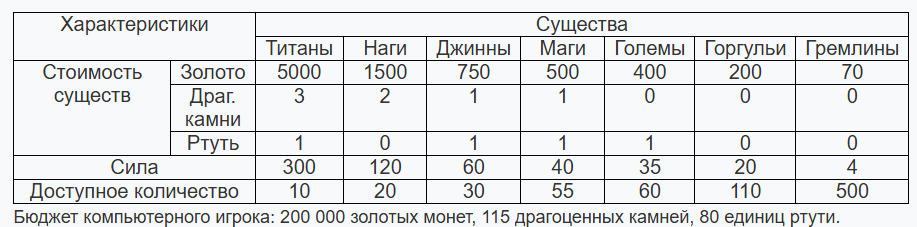\
Компьютерному игроку необходимо максимизировать силу нанятой им армии, но при этом необходимо, чтобы суммарная сила существ дальнего боя (титаны, маги и гремлины) была не меньше 4 000 единиц, а летающих существ (джиннов и горгулий – не меньше 2000. Рынка для продажи ресурсов в городе нет. Сформулируйте математическую модель задачи и найдите оптимальное решение. Используйте сервис «Поиск решения в Excel» или библиотеки языка Python.

In [ ]:
prob = pulp.LpProblem("Maximize_Army_Strength", pulp.LpMaximize)

# Существа: Титаны, Наги, Джинны, Маги, Големы, Горгульи, Гремлины
creatures = ['Титаны', 'Наги', 'джинны', 'Маги', 'Големы', 'Гаргульи', 'Гремлины']
cost_gold = [5000, 1500, 750, 500, 400, 200, 70]
cost_gems = [3, 2, 1, 1, 0, 0, 0]
cost_mercury = [1, 0, 1, 1, 1, 0, 0]
strength = [300, 120, 60, 40, 35, 20, 4]
max_available = [10, 20, 30, 55, 60, 110, 500]

# Переменные (количество каждого существа)
x = [pulp.LpVariable(f'x_{creature}', lowBound=0, upBound=max_available[i], cat='Integer')
     for i, creature in enumerate(creatures)]

# Целевая функция: максимизация силы
prob += pulp.lpSum([strength[i] * x[i] for i in range(len(creatures))])

# Ограничения по ресурсам
prob += pulp.lpSum([cost_gold[i] * x[i] for i in range(len(creatures))]) <= 200000, "Gold"
prob += pulp.lpSum([cost_gems[i] * x[i] for i in range(len(creatures))]) <= 115, "Gems"
prob += pulp.lpSum([cost_mercury[i] * x[i] for i in range(len(creatures))]) <= 80, "Mercury"

# Дополнительные условия
# Сила дальнего боя (Титаны, Маги, Гремлины) >= 4000
prob += 300 * x[0] + 40 * x[3] + 4 * x[6] >= 4000, "Ranged_Strength"
# Летающие существа (Джинны, Горгульи) >= 2000
prob += 60 * x[2] + 20 * x[5] >= 2000, "Flying_Strength"

# Решаем задачу
prob.solve()

print("\nОптимальный состав армии:")
for i, creature in enumerate(creatures):
     print(f"{creature}: {int(x[i].varValue)}")
print(f"Общая сила армии: {pulp.value(prob.objective)}")
print(f"Проверка ограничений:")
print(f"Золото: {sum(cost_gold[i] * x[i].varValue for i in range(len(creatures)))} / 200000")
print(f"Драгоценные камни: {sum(cost_gems[i] * x[i].varValue for i in range(len(creatures)))} / 115")
print(f"Ртуть: {sum(cost_mercury[i] * x[i].varValue for i in range(len(creatures)))} / 80")
print(f"Сила дальнего боя: {300 * x[0].varValue + 40 * x[3].varValue + 4 * x[6].varValue} (требуется >= 4000)")
print(f"Сила летающих существ: {60 * x[2].varValue + 20 * x[5].varValue} (требуется >= 2000)")



Оптимальный состав армии:
Титаны: 10
Наги: 20
джинны: 30
Маги: 15
Големы: 25
Гаргульи: 110
Гремлины: 500
Общая сила армии: 12875.0
Проверка ограничений:
Золото: 177000.0 / 200000
Драгоценные камни: 115.0 / 115
Ртуть: 80.0 / 80
Сила дальнего боя: 5600.0 (требуется >= 4000)
Сила летающих существ: 4000.0 (требуется >= 2000)


# Задание 3
Решить транспортную задачу
Из трех холодильников А1, А2 и А3, вмещающих мороженную рыбу в количествах 320, 280 и 350 т, необходимо последнюю доставить в пять магазинов В1, В2, В3, В4 и В5 в количествах 140, 110, 230, 150 и 220 т. Известны стоимости перевозки 1т рыбы из холодильника в магазин.
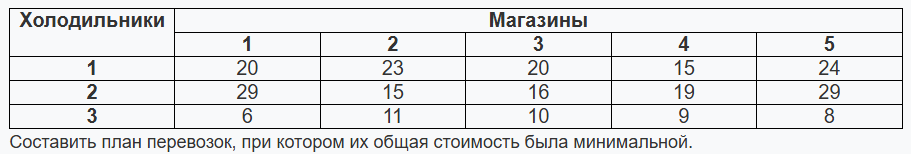

In [ ]:
# Данные транспортной задачи
supply = [320, 280, 350]  # A1, A2, A3
demand = [140, 110, 230, 150, 220]  # B1, B2, B3, B4, B5
costs = [
        [20, 23, 20, 15, 24],
        [29, 15, 16, 19, 29],
        [6, 11, 10, 9, 8]
        ]

# Создаем задачу минимизации
prob = pulp.LpProblem("Transportation_Problem", pulp.LpMinimize)

# Переменные: количество перевозимого из i в j
routes = [(i, j) for i in range(len(supply)) for j in range(len(demand))]
x = pulp.LpVariable.dicts("Route", (range(len(supply)), range(len(demand))), lowBound=0, cat='Continuous')

# Целевая функция: минимизация стоимости перевозок
prob += pulp.lpSum([x[i][j] * costs[i][j] for (i, j) in routes])

# Ограничения по предложению
for i in range(len(supply)):
    prob += pulp.lpSum([x[i][j] for j in range(len(demand))]) <= supply[i], f"Supply_{i}"

# Ограничения по спросу
for j in range(len(demand)):
    prob += pulp.lpSum([x[i][j] for i in range(len(supply))]) >= demand[j], f"Demand_{j}"

# Решаем задачу
prob.solve()

print("\nОптимальный план перевозок:")
total_cost = 0
for i in range(len(supply)):
     for j in range(len(demand)):
         if x[i][j].varValue > 0:
            print(f"Из холодильника A{i+1} в магазин B{j+1}: {x[i][j].varValue} т")
            total_cost += x[i][j].varValue * costs[i][j]
print(f"Общая стоимость перевозок: {total_cost} у.е.")


Оптимальный план перевозок:
Из холодильника A1 в магазин B1: 10.0 т
Из холодильника A1 в магазин B3: 60.0 т
Из холодильника A1 в магазин B4: 150.0 т
Из холодильника A2 в магазин B2: 110.0 т
Из холодильника A2 в магазин B3: 170.0 т
Из холодильника A3 в магазин B1: 130.0 т
Из холодильника A3 в магазин B5: 220.0 т
Общая стоимость перевозок: 10560.0 у.е.
